In [4]:
import pandas as pd

# 读取数据
df = pd.read_csv('./SPEQ/test_20250705/out/results/results_0.csv')  # 如果是tsv，改为sep='\t'

# 按0.5为阈值进行预测
df['Pred'] = (df['Score'] > 0).astype(int)

# 计算混淆矩阵
TP = ((df['Label'] == 1) & (df['Pred'] == 1)).sum()
FP = ((df['Label'] == 0) & (df['Pred'] == 1)).sum()
TN = ((df['Label'] == 0) & (df['Pred'] == 0)).sum()
FN = ((df['Label'] == 1) & (df['Pred'] == 0)).sum()

# 计算指标
accuracy = (TP + TN) / (TP + FP + TN + FN)
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"TP: {TP}")
print(f"FP: {FP}")
print(f"TN: {TN}")
print(f"FN: {FN}")
print(f"准确率: {accuracy:.4f}")
print(f"召回率: {recall:.4f}")
print(f"特异性: {specificity:.4f}")
print(f"精确率: {precision:.4f}")
print(f"F1分数: {f1:.4f}")

TP: 12685
FP: 8204
TN: 11626
FN: 5968
准确率: 0.6317
召回率: 0.6801
特异性: 0.5863
精确率: 0.6073
F1分数: 0.6416


In [3]:
df.head()

,Spectrum,Label,Score,Pred
0,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_...,1.0,-0.492287,0
1,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_...,1.0,0.514125,1
2,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_...,0.0,-0.148443,0
3,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_...,1.0,0.773303,1
4,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_...,1.0,0.595445,1


In [2]:
df['Label'].value_counts()

Label
0.0    19830
1.0    18653
Name: count, dtype: int64

/tmp/ipykernel_34247/3124544882.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(['score_bin', 'Label']).size().unstack(fill_value=0)


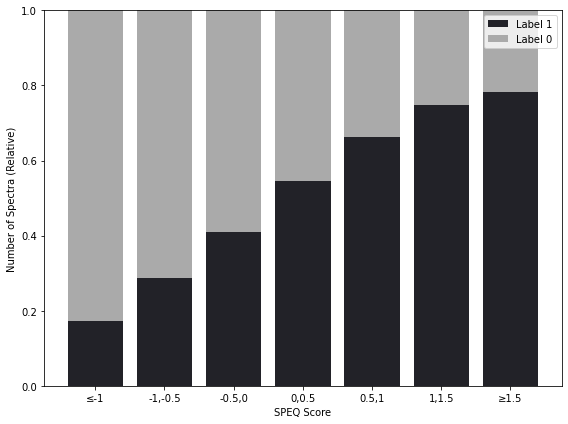

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_csv('./SPEQ/test_20250705/out/results/results_0.csv')  # 如果是tsv，改为sep='\t'

# 设定score区间
bins = [-np.inf, -1, -0.5, 0, 0.5, 1, 1.5, np.inf]
labels = ['≤-1', '-1,-0.5', '-0.5,0', '0,0.5', '0.5,1', '1,1.5', '≥1.5']

# 分箱
df['score_bin'] = pd.cut(df['Score'], bins=bins, labels=labels, right=True, include_lowest=True)

# 统计每个区间内label=1和label=0的数量
grouped = df.groupby(['score_bin', 'Label']).size().unstack(fill_value=0)

# 计算每个区间的总数和相对比例
grouped_rel = grouped.div(grouped.sum(axis=1), axis=0)

# 绘图
fig, ax = plt.subplots(figsize=(8, 6))
bottom = np.zeros(len(grouped_rel))
colors = ['#222228', '#aaaaaa']  # 深色为label=1，浅色为label=0

for i, label_val in enumerate([1, 0]):
    vals = grouped_rel[label_val] if label_val in grouped_rel.columns else np.zeros(len(grouped_rel))
    ax.bar(grouped_rel.index, vals, bottom=bottom, color=colors[i], label=f'Label {label_val}')
    bottom += vals

ax.set_ylabel('Number of Spectra (Relative)')
ax.set_xlabel('SPEQ Score')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

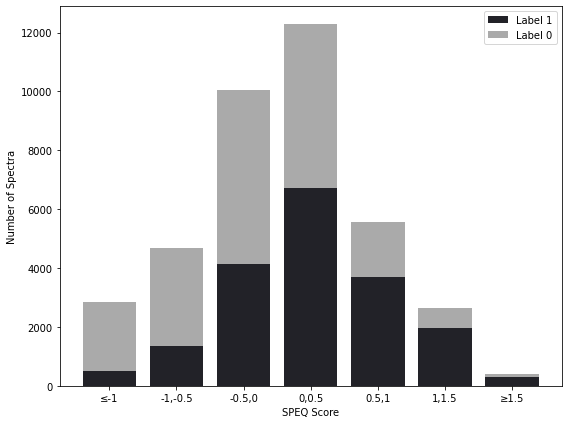

In [6]:
# 统计每个区间内label=1和label=0的数量
# grouped = df.groupby(['score_bin', 'Label']).size().unstack(fill_value=0)

# 绘图（绝对数量）
fig, ax = plt.subplots(figsize=(8, 6))
bottom = np.zeros(len(grouped))
colors = ['#222228', '#aaaaaa']  # 深色为label=1，浅色为label=0

for i, label_val in enumerate([1, 0]):
    vals = grouped[label_val] if label_val in grouped.columns else np.zeros(len(grouped))
    ax.bar(grouped.index, vals, bottom=bottom, color=colors[i], label=f'Label {label_val}')
    bottom += vals

ax.set_ylabel('Number of Spectra')
ax.set_xlabel('SPEQ Score')
ax.legend()
plt.tight_layout()
plt.show()

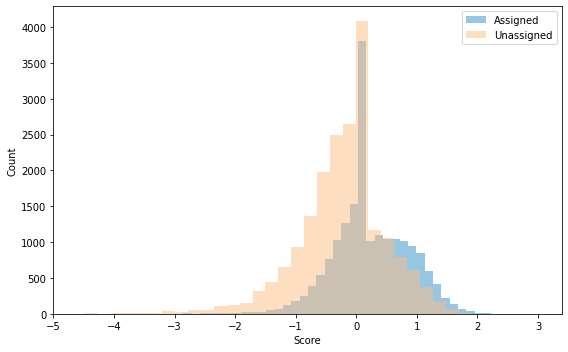

In [8]:
# 分别取出两类
assigned = df[df['Label'] == 1]['Score']
unassigned = df[df['Label'] == 0]['Score']

# 绘制重叠直方图
plt.figure(figsize=(8, 5))
plt.hist(assigned, bins=100, alpha=0.7, label='Assigned', color='#6baed6')
plt.hist(unassigned, bins=100, alpha=0.5, label='Unassigned', color='#fdbe85')
plt.xlabel('Score')
plt.ylabel('Count')
plt.legend()
plt.xlim(-5, None)  # 只显示Score > -5
plt.tight_layout()
plt.show()